In [1]:
import os
import warnings
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.exceptions import ConvergenceWarning
import src.dataset_generator as dataset_generator
import src.auxiliar as aux
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import tensorflow as tf

SMALL_SIZE = 10+2
MEDIUM_SIZE = 14+2
BIGGER_SIZE = 18+2

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=BIGGER_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

reds = aux.CustomCmap([60/255,60/255,60/255], [196/255,60/255,60/255])
greens = aux.CustomCmap([0.1, 0.3, 0.1], [0.1, 0.8, 0.1])
blues = aux.CustomCmap([60/255,60/255,60/255], [45/255,159/255,255/255])
teals = aux.CustomCmap([60/255,60/255,60/255], [0/255,200/255,130/255])

class_colors = ['#2D9FFF', '#FF5154', '#E5D352', '#00C882']
model_colors = ['#2D9FFF', '#FF5154', '#E5D352', '#00C882']


# We choose the size big enough to see the scalability of the algorithms, but not too big to avoid too long running times
n_samples = 500

2025-02-02 23:34:49.746032: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-02-02 23:34:49.753919: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1738557289.763166   11525 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1738557289.765894   11525 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-02-02 23:34:49.775635: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

In [2]:
def train_mlp(x_train, y_train, x_test, y_test):

	def create_model(num_classes):
		model = tf.keras.Sequential([
			tf.keras.layers.Dense(1024, activation='relu'),
			tf.keras.layers.Dense(1024, activation='relu'),
			tf.keras.layers.Dense(512, activation='relu'),
			tf.keras.layers.Dense(512, activation='relu'),
			tf.keras.layers.Dense(256, activation='relu'),
			tf.keras.layers.Dense(128, activation='relu'),
			tf.keras.layers.Dense(num_classes, activation='softmax')
		])
		return model

	# Prepare the data
	train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train)).shuffle(10000).batch(32)
	test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test)).batch(1024)

	# Define model
	model = create_model(2)
	model.compile(
		optimizer='adam',
		loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
		metrics=['accuracy'],
	)

	# Train the model
	history = model.fit(train_ds, epochs=100, verbose=0, validation_data=test_ds)
	train_acc = history.history['accuracy']
	test_acc = history.history['val_accuracy']

	del model
	del train_ds
	del test_ds
	del history

	return np.stack(train_acc), np.stack(test_acc)

In [3]:
x = np.arange(0,1,0.0001)
raw_1 = lambda x : 1 - x
raw_2 = lambda x : x
raws = [raw_1, raw_2]
domain = [0,1]
sample_points = [10,25,50,75,100, 500, 1000, 5000, 10000, 50000]

In [ ]:
train_scores, test_scores = [], []
for s in tqdm(sample_points):
	train_ss, test_ss = [], []
	for _ in range(100):
		x_data, y_data = dataset_generator.generate_one_dim_dataset_from_functions(raws, domain, s, resolution=10000, force_balance=True)
		x_data = x_data.reshape(-1,1)
		clf = RandomForestClassifier(n_estimators=10, max_depth=5)
		clf = make_pipeline(StandardScaler(), clf)
		clf.fit(x_data, y_data)

		score = clf.score(x_data, y_data)
		train_ss.append(score)

		x_data, y_data = dataset_generator.generate_one_dim_dataset_from_functions(raws, domain, s, resolution=10000, force_balance=True)
		x_data = x_data.reshape(-1,1)
		score = clf.score(x_data, y_data)
		test_ss.append(score)

	train_scores.append(train_ss)
	test_scores.append(test_ss)

data_path = './data/tree_example'
os.makedirs(data_path, exist_ok=True)
np.save(os.path.join(data_path, 'rfc_train_scores_v2.npy'), train_scores)
np.save(os.path.join(data_path, 'rfc_test_scores_v2.npy'), test_scores)

In [24]:
train_scores, test_scores = [], []
for s in tqdm(sample_points):
	train_ss, test_ss = [], []
	for _ in range(10):

		with warnings.catch_warnings():
			warnings.filterwarnings("ignore", category=ConvergenceWarning)

			x_data, y_data = dataset_generator.generate_one_dim_dataset_from_functions(raws, domain, s, resolution=10000, force_balance=True)
			x_data = x_data.reshape(-1,1)

			clf = MLPClassifier(hidden_layer_sizes=[128,64,32], alpha=0, batch_size=32)
			clf = make_pipeline(StandardScaler(), clf)
			clf.fit(x_data, y_data)

			score = clf.score(x_data, y_data)
			train_ss.append(score)

			x_data, y_data = dataset_generator.generate_one_dim_dataset_from_functions(raws, domain, s, resolution=10000, force_balance=True)
			x_data = x_data.reshape(-1,1)
			score = clf.score(x_data, y_data)
			test_ss.append(score)

	train_scores.append(train_ss)
	test_scores.append(test_ss)

data_path = './data/tree_example'
os.makedirs(data_path, exist_ok=True)
np.save(os.path.join(data_path, 'mlp_train_scores_v2.npy'), train_scores)
np.save(os.path.join(data_path, 'mlp_test_scores_v2.npy'), test_scores)

  0%|          | 0/10 [00:00<?, ?it/s]/home/nogar/Project/the-art-of-misclassification/.env/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:608: UserWarning: Got `batch_size` less than 1 or larger than sample size. It is going to be clipped
  warnings.warn(
/home/nogar/Project/the-art-of-misclassification/.env/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:608: UserWarning: Got `batch_size` less than 1 or larger than sample size. It is going to be clipped
  warnings.warn(
/home/nogar/Project/the-art-of-misclassification/.env/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:608: UserWarning: Got `batch_size` less than 1 or larger than sample size. It is going to be clipped
  warnings.warn(
/home/nogar/Project/the-art-of-misclassification/.env/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:608: UserWarning: Got `batch_size` less than 1 or larger than sample size. It is

In [ ]:
train_scores, test_scores = [], []
for s in tqdm(sample_points):
	train_ss, test_ss = [], []
	for _ in range(10):

		with warnings.catch_warnings():
			warnings.filterwarnings("ignore", category=ConvergenceWarning)

			x_train, y_train = dataset_generator.generate_one_dim_dataset_from_functions(raws, domain, s, resolution=10000, force_balance=True)
			x_train = x_train.reshape(-1,1)
			x_test, y_test = dataset_generator.generate_one_dim_dataset_from_functions(raws, domain, s, resolution=10000, force_balance=True)
			x_test = x_test.reshape(-1,1)

			scaler = StandardScaler()
			x_train_transform = scaler.fit_transform(x_train)
			x_test_transform = scaler.transform(x_test)

			train_acc, test_acc = train_mlp(x_train_transform, y_train, x_test_transform, y_test)

			train_ss.append(train_acc)
			test_ss.append(test_acc)

	train_scores.append(np.stack(train_ss))
	test_scores.append(np.stack(test_ss))

data_path = './data/tree_example'
os.makedirs(data_path, exist_ok=True)
np.save(os.path.join(data_path, 'mlp_large_train_scores.npy'), train_scores)
np.save(os.path.join(data_path, 'mlp_large_test_scores.npy'), test_scores)

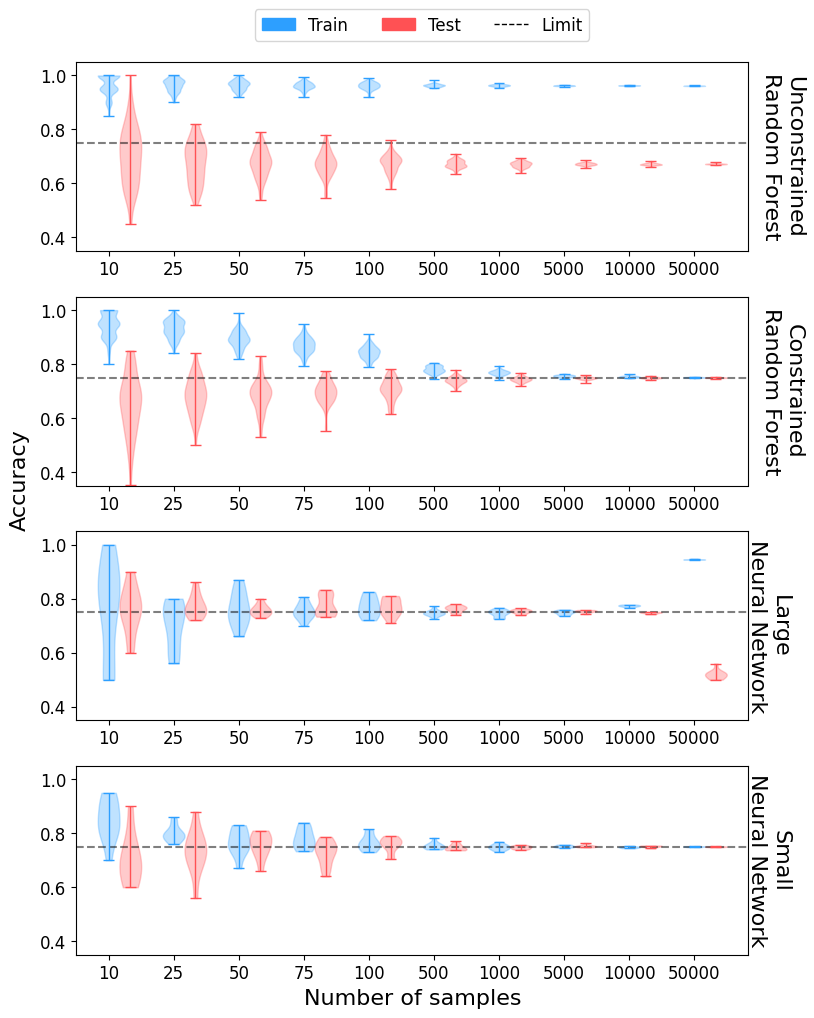

In [46]:
limit = 3/4
data_path = './data/tree_example'
sample_points = np.array([10,25,50,75,100, 500, 1000, 5000, 10000, 50000])

fig, ax = plt.subplots(4,1,figsize=(8,10))
pos = 3*np.arange(len(sample_points))
for i in range(4):
	ax[i].plot([-1.5, 3*len(sample_points)+1.5], [limit, limit], 'k--', alpha=0.5)

train_scores = np.load(os.path.join(data_path, 'rfc_train_scores.npy'))
test_scores = np.load(os.path.join(data_path, 'rfc_test_scores.npy'))
parts = ax[0].violinplot(list(train_scores), positions=pos, widths=1)
for pc in parts['bodies']:
    pc.set_facecolor(model_colors[0])
    pc.set_edgecolor(model_colors[0])
    pc.set_alpha(0.3)
for partname in ('cbars','cmins','cmaxes'):
    vp = parts[partname]
    vp.set_edgecolor(model_colors[0])
    vp.set_linewidth(1)

parts = ax[0].violinplot(list(test_scores), positions=pos+1, widths=1)
for pc in parts['bodies']:
    pc.set_facecolor(model_colors[1])
    pc.set_edgecolor(model_colors[1])
    pc.set_alpha(0.3)
for partname in ('cbars','cmins','cmaxes'):
    vp = parts[partname]
    vp.set_edgecolor(model_colors[1])
    vp.set_linewidth(1)

train_scores = np.load(os.path.join(data_path, 'rfc_train_scores_v2.npy'))
test_scores = np.load(os.path.join(data_path, 'rfc_test_scores_v2.npy'))
parts = ax[1].violinplot(list(train_scores), positions=pos, widths=1)
for pc in parts['bodies']:
    pc.set_facecolor(model_colors[0])
    pc.set_edgecolor(model_colors[0])
    pc.set_alpha(0.3)
for partname in ('cbars','cmins','cmaxes'):
    vp = parts[partname]
    vp.set_edgecolor(model_colors[0])
    vp.set_linewidth(1)

parts = ax[1].violinplot(list(test_scores), positions=pos+1, widths=1)
for pc in parts['bodies']:
    pc.set_facecolor(model_colors[1])
    pc.set_edgecolor(model_colors[1])
    pc.set_alpha(0.3)
for partname in ('cbars','cmins','cmaxes'):
    vp = parts[partname]
    vp.set_edgecolor(model_colors[1])
    vp.set_linewidth(1)

train_scores = np.load(os.path.join(data_path, 'mlp_train_scores_v2.npy'))
test_scores = np.load(os.path.join(data_path, 'mlp_test_scores_v2.npy'))
parts = ax[3].violinplot(list(train_scores), positions=pos, widths=1)
for pc in parts['bodies']:
    pc.set_facecolor(model_colors[0])
    pc.set_edgecolor(model_colors[0])
    pc.set_alpha(0.3)
for partname in ('cbars','cmins','cmaxes'):
    vp = parts[partname]
    vp.set_edgecolor(model_colors[0])
    vp.set_linewidth(1)

parts = ax[3].violinplot(list(test_scores), positions=pos+1, widths=1)
for pc in parts['bodies']:
    pc.set_facecolor(model_colors[1])
    pc.set_edgecolor(model_colors[1])
    pc.set_alpha(0.3)
for partname in ('cbars','cmins','cmaxes'):
    vp = parts[partname]
    vp.set_edgecolor(model_colors[1])
    vp.set_linewidth(1)


train_scores_raw = np.load(os.path.join(data_path, 'mlp_large_train_scores.npy'))
test_scores_raw = np.load(os.path.join(data_path, 'mlp_large_test_scores.npy'))
train_scores, test_scores= [], []
for s in range(len(sample_points)):
	idx = np.argmax(test_scores_raw[s,:,:], axis=-1)
	train_scores.append([train_scores_raw[s,j,k] for j, k in enumerate(idx)])
	test_scores.append([test_scores_raw[s,j,k] for j, k in enumerate(idx)])
parts = ax[2].violinplot(train_scores, positions=pos, widths=1)
for pc in parts['bodies']:
    pc.set_facecolor(model_colors[0])
    pc.set_edgecolor(model_colors[0])
    pc.set_alpha(0.3)
for partname in ('cbars','cmins','cmaxes'):
    vp = parts[partname]
    vp.set_edgecolor(model_colors[0])
    vp.set_linewidth(1)

parts = ax[2].violinplot(test_scores, positions=pos+1, widths=1)
for pc in parts['bodies']:
    pc.set_facecolor(model_colors[1])
    pc.set_edgecolor(model_colors[1])
    pc.set_alpha(0.3)
for partname in ('cbars','cmins','cmaxes'):
    vp = parts[partname]
    vp.set_edgecolor(model_colors[1])
    vp.set_linewidth(1)

legend_elements = [Patch(facecolor=model_colors[0], edgecolor=model_colors[0], label='Train'), 
                   Patch(facecolor=model_colors[1], edgecolor=model_colors[1], label='Test'),
                   Line2D([0], [0], color='k', lw=1, linestyle='--', label='Limit')]
fig.legend(handles=legend_elements, ncols=3, bbox_to_anchor=(0.5, 1.025), loc='upper center')

fig.suptitle('')

for i in range(4):
	ax[i].set_xlim(-1.5, 3*len(sample_points)-0.5)
	ax[i].set_ylim(0.35, 1.05)
	ax[i].set_xticks(pos, sample_points)
	#ax[i].legend(handles=legend_elements, ncols=1, loc='lower right')
ax[3].set_xlabel('Number of samples')

label = fig.text(-0.015,0.5,'Accuracy', rotation=90, fontsize=MEDIUM_SIZE)
ax[0].set_ylabel('Unconstrained\nRandom Forest', rotation=270, labelpad=40)
ax[0].yaxis.set_label_position("right")
ax[1].set_ylabel('Constrained\nRandom Forest', rotation=270, labelpad=40)
ax[1].yaxis.set_label_position("right")
ax[3].set_ylabel('Small\nNeural Network', rotation=270, labelpad=30)
ax[3].yaxis.set_label_position("right")
ax[2].set_ylabel('Large\nNeural Network', rotation=270, labelpad=30)
ax[2].yaxis.set_label_position("right")

plt.tight_layout()
plt.savefig('./images/why_example.png', dpi=300, bbox_inches='tight')
plt.show()

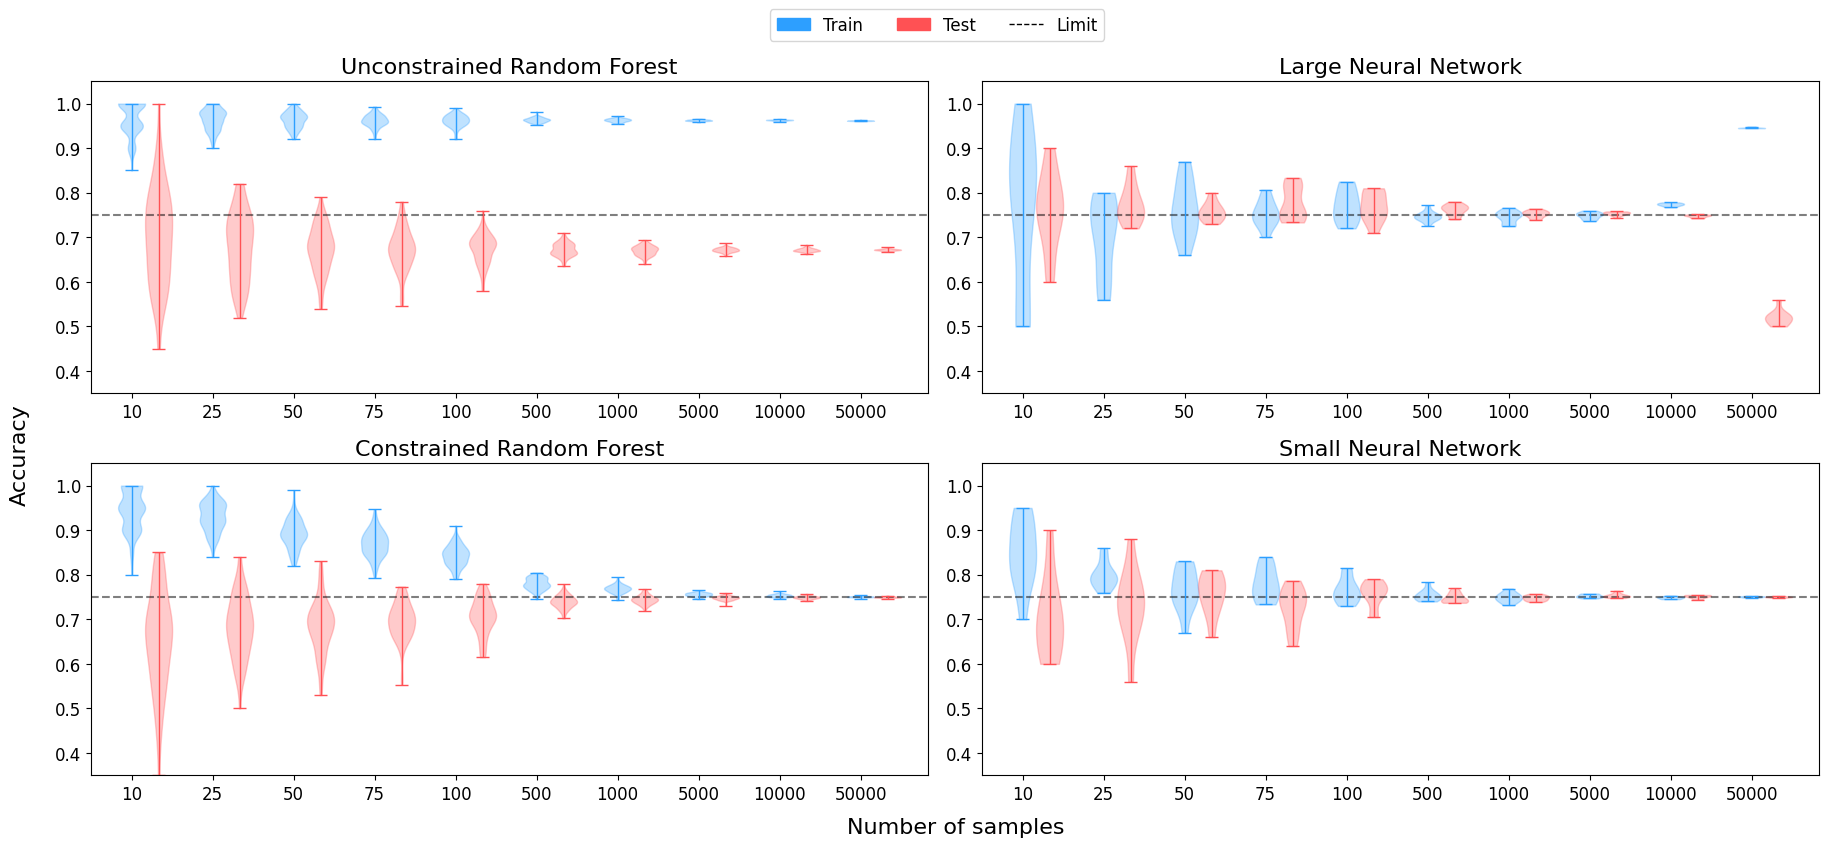

In [36]:
limit = 3/4
data_path = './data/tree_example'
sample_points = np.array([10,25,50,75,100, 500, 1000, 5000, 10000, 50000])

fig, ax = plt.subplots(2,2,figsize=(18,8))
pos = 3*np.arange(len(sample_points))
for i in range(4):
	ax[i//2, i%2].plot([-1.5, 3*len(sample_points)+1.5], [limit, limit], 'k--', alpha=0.5)

train_scores = np.load(os.path.join(data_path, 'rfc_train_scores.npy'))
test_scores = np.load(os.path.join(data_path, 'rfc_test_scores.npy'))
parts = ax[0,0].violinplot(list(train_scores), positions=pos, widths=1)
for pc in parts['bodies']:
    pc.set_facecolor(model_colors[0])
    pc.set_edgecolor(model_colors[0])
    pc.set_alpha(0.3)
for partname in ('cbars','cmins','cmaxes'):
    vp = parts[partname]
    vp.set_edgecolor(model_colors[0])
    vp.set_linewidth(1)

parts = ax[0,0].violinplot(list(test_scores), positions=pos+1, widths=1)
for pc in parts['bodies']:
    pc.set_facecolor(model_colors[1])
    pc.set_edgecolor(model_colors[1])
    pc.set_alpha(0.3)
for partname in ('cbars','cmins','cmaxes'):
    vp = parts[partname]
    vp.set_edgecolor(model_colors[1])
    vp.set_linewidth(1)

train_scores = np.load(os.path.join(data_path, 'rfc_train_scores_v2.npy'))
test_scores = np.load(os.path.join(data_path, 'rfc_test_scores_v2.npy'))
parts = ax[1,0].violinplot(list(train_scores), positions=pos, widths=1)
for pc in parts['bodies']:
    pc.set_facecolor(model_colors[0])
    pc.set_edgecolor(model_colors[0])
    pc.set_alpha(0.3)
for partname in ('cbars','cmins','cmaxes'):
    vp = parts[partname]
    vp.set_edgecolor(model_colors[0])
    vp.set_linewidth(1)

parts = ax[1,0].violinplot(list(test_scores), positions=pos+1, widths=1)
for pc in parts['bodies']:
    pc.set_facecolor(model_colors[1])
    pc.set_edgecolor(model_colors[1])
    pc.set_alpha(0.3)
for partname in ('cbars','cmins','cmaxes'):
    vp = parts[partname]
    vp.set_edgecolor(model_colors[1])
    vp.set_linewidth(1)

train_scores = np.load(os.path.join(data_path, 'mlp_train_scores_v2.npy'))
test_scores = np.load(os.path.join(data_path, 'mlp_test_scores_v2.npy'))
parts = ax[1,1].violinplot(list(train_scores), positions=pos, widths=1)
for pc in parts['bodies']:
    pc.set_facecolor(model_colors[0])
    pc.set_edgecolor(model_colors[0])
    pc.set_alpha(0.3)
for partname in ('cbars','cmins','cmaxes'):
    vp = parts[partname]
    vp.set_edgecolor(model_colors[0])
    vp.set_linewidth(1)

parts = ax[1,1].violinplot(list(test_scores), positions=pos+1, widths=1)
for pc in parts['bodies']:
    pc.set_facecolor(model_colors[1])
    pc.set_edgecolor(model_colors[1])
    pc.set_alpha(0.3)
for partname in ('cbars','cmins','cmaxes'):
    vp = parts[partname]
    vp.set_edgecolor(model_colors[1])
    vp.set_linewidth(1)


train_scores_raw = np.load(os.path.join(data_path, 'mlp_large_train_scores.npy'))
test_scores_raw = np.load(os.path.join(data_path, 'mlp_large_test_scores.npy'))
train_scores, test_scores= [], []
for s in range(len(sample_points)):
	idx = np.argmax(test_scores_raw[s,:,:], axis=-1)
	train_scores.append([train_scores_raw[s,j,k] for j, k in enumerate(idx)])
	test_scores.append([test_scores_raw[s,j,k] for j, k in enumerate(idx)])

parts = ax[0,1].violinplot(train_scores, positions=pos, widths=1)
for pc in parts['bodies']:
    pc.set_facecolor(model_colors[0])
    pc.set_edgecolor(model_colors[0])
    pc.set_alpha(0.3)
for partname in ('cbars','cmins','cmaxes'):
    vp = parts[partname]
    vp.set_edgecolor(model_colors[0])
    vp.set_linewidth(1)

parts = ax[0,1].violinplot(test_scores, positions=pos+1, widths=1)
for pc in parts['bodies']:
    pc.set_facecolor(model_colors[1])
    pc.set_edgecolor(model_colors[1])
    pc.set_alpha(0.3)
for partname in ('cbars','cmins','cmaxes'):
    vp = parts[partname]
    vp.set_edgecolor(model_colors[1])
    vp.set_linewidth(1)

legend_elements = [Patch(facecolor=model_colors[0], edgecolor=model_colors[0], label='Train'), 
                   Patch(facecolor=model_colors[1], edgecolor=model_colors[1], label='Test'),
                   Line2D([0], [0], color='k', lw=1, linestyle='--', label='Limit')]
fig.legend(handles=legend_elements, ncols=3, bbox_to_anchor=(0.5, 1.025), loc='upper center')

fig.suptitle('')

for i in range(4):
	ax[i//2, i%2].set_xlim(-1.5, 3*len(sample_points)-0.5)
	ax[i//2, i%2].set_ylim(0.35, 1.05)
	ax[i//2, i%2].set_xticks(pos, sample_points)
	#axax[i//2, i%2].legend(handles=legend_elements, ncols=1, loc='lower right')
#ax[3].set_xlabel('Number of samples')

label = fig.text(-0.015,0.5-0.1,'Accuracy', rotation=90, fontsize=MEDIUM_SIZE)
label2 = fig.text(0.5-0.05,-0.015,'Number of samples', fontsize=MEDIUM_SIZE)

#ax[0,0].set_ylabel('Unconstrained\nRandom Forest', rotation=270, labelpad=40)
#ax[0,0].yaxis.set_label_position("right")
#ax[1,0].set_ylabel('Constrained\nRandom Forest', rotation=270, labelpad=40)
#ax[1,0].yaxis.set_label_position("right")
#ax[0,1].set_ylabel('Small\nNeural Network', rotation=270, labelpad=40)
#ax[0,1].yaxis.set_label_position("right")
#ax[1,1].set_ylabel('Large\nNeural Network', rotation=270, labelpad=40)
#ax[1,1].yaxis.set_label_position("right")

ax[0,0].set_title('Unconstrained Random Forest', fontsize=MEDIUM_SIZE)
ax[1,0].set_title('Constrained Random Forest', fontsize=MEDIUM_SIZE)
ax[1,1].set_title('Small Neural Network', fontsize=MEDIUM_SIZE)
ax[0,1].set_title('Large Neural Network', fontsize=MEDIUM_SIZE)

plt.tight_layout()
plt.savefig('./images/why_example.png', dpi=300, bbox_inches='tight')
plt.show()

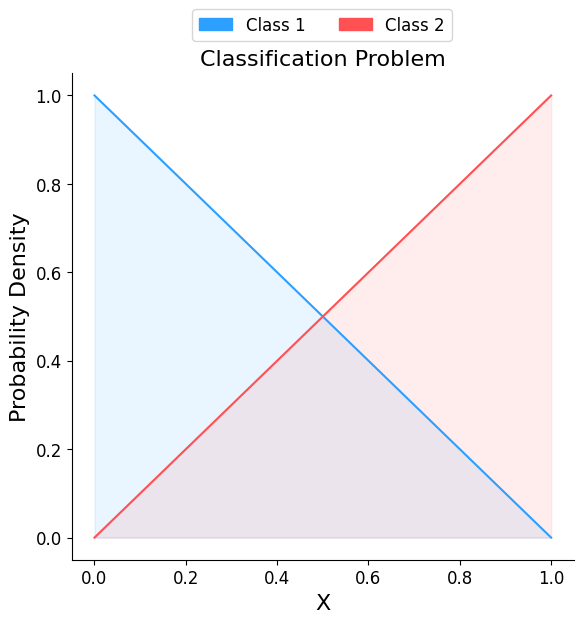

In [35]:
fig, ax = plt.subplots(1,1,figsize=(6,6))
x = np.linspace(0,1,100)
colors = ['#2D9FFF', '#FF5154']
ax.fill_between(x, 0, 1-x, color=colors[0], alpha=0.1)
ax.plot(x, 1-x, color=colors[0])
ax.fill_between(x, 0, x, color=colors[1], alpha=0.1)
ax.plot(x, x, color=colors[1])
ax.set_ylabel('Probability Density')
ax.set_xlabel('X')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_title('Classification Problem', fontsize=MEDIUM_SIZE)
legend_elements = [Patch(facecolor=model_colors[0], edgecolor=colors[0], label='Class 1'), 
                   Patch(facecolor=model_colors[1], edgecolor=colors[1], label='Class 2')]
fig.legend(handles=legend_elements, ncols=2, bbox_to_anchor=(0.55, 1.05), loc='upper center')

plt.tight_layout()
plt.savefig('./images/problem_reference.png', dpi=300, bbox_inches='tight')
plt.show()